# Clase 7 — Pandas + Matplotlib: integración

**Python y Políticas Públicas**

---

## Contenidos
1. Gráficos directamente desde pandas
2. Exploración visual de distribuciones
3. Visualizar series temporales con pandas
4. Detección visual de outliers (boxplots)
5. Dashboard completo: análisis exploratorio de un dataset
6. Exportar figuras de calidad de publicación
7. Ejercicios

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)

# Dataset de indicadores provinciales (simulado pero realista)
np.random.seed(42)
provincias = [
    "CABA", "Buenos Aires", "Córdoba", "Santa Fe", "Mendoza",
    "Tucumán", "Salta", "Entre Ríos", "Chaco", "Misiones",
    "Corrientes", "Santiago del Estero", "Jujuy", "Río Negro", "Neuquén",
    "Formosa", "San Juan", "San Luis", "Catamarca", "La Rioja",
    "La Pampa", "Chubut", "Santa Cruz", "Tierra del Fuego"
]
n = len(provincias)

df = pd.DataFrame({
    'provincia': provincias,
    'region': ['AMBA', 'Pampeana', 'Pampeana', 'Pampeana', 'Cuyo',
                       'NOA', 'NOA', 'Pampeana', 'NEA', 'NEA',
                       'NEA', 'NOA', 'NOA', 'Patagonia', 'Patagonia',
                       'NEA', 'Cuyo', 'Cuyo', 'NOA', 'NOA',
                       'Pampeana', 'Patagonia', 'Patagonia', 'Patagonia'],
    'poblacion_miles': [3_100, 17_500, 3_900, 3_600, 1_950,
                        1_700, 1_500, 1_350, 1_200, 1_280,
                        1_050, 980, 780, 720, 680,
                        610, 790, 510, 430, 390,
                        365, 620, 380, 180],
    'pobreza_2021': np.random.uniform(15, 62, n).round(1),
    'pobreza_2022': np.random.uniform(14, 60, n).round(1),
    'pobreza_2023': np.random.uniform(13, 58, n).round(1),
    'desempleo_2023': np.random.uniform(3, 15, n).round(1),
    'gasto_salud_pct': np.random.uniform(8, 20, n).round(1),
    'gasto_educacion_pct': np.random.uniform(10, 25, n).round(1),
    'pbi_pc_miles': np.random.uniform(4, 18, n).round(1),
})

# Correlación realista: más pobreza → menos PBI per cápita
df['pbi_pc_miles'] = (20 - df['pobreza_2023'] * 0.25 + np.random.normal(0, 1.5, n)).clip(3, 20).round(1)

print(f"Dataset: {df.shape}")
df.head()

Dataset: (24, 10)


,provincia,region,poblacion_miles,pobreza_2021,pobreza_2022,pobreza_2023,desempleo_2023,gasto_salud_pct,gasto_educacion_pct,pbi_pc_miles
0,CABA,AMBA,3100,32.6,35.0,37.6,3.1,14.3,22.1,10.7
1,Buenos Aires,Pampeana,17500,59.7,50.1,21.3,12.8,13.1,23.4,13.9
2,Córdoba,Pampeana,3900,49.4,23.2,56.6,11.5,8.3,14.8,3.5
3,Santa Fe,Pampeana,3600,43.1,37.7,47.9,11.7,9.3,11.7,8.1
4,Mendoza,Cuyo,1950,22.3,41.3,55.3,12.3,8.4,13.4,4.6


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- Paleta de identidad del curso ---
C = ['#2A6496', '#E07B3F', '#3D9970', '#8E5EA2', '#C0A830', '#637A8A']

mpl.rcParams.update({
    'figure.figsize'       : (10, 5),
    'font.size'            : 11,
    'axes.titlesize'       : 12,
    'axes.titleweight'     : 'normal',
    'axes.spines.top'      : False,
    'axes.spines.right'    : False,
    'legend.frameon'       : False,
    'axes.prop_cycle'      : mpl.cycler(color=C),
    'figure.dpi'           : 110,
})

def tit(ax, t, **kw):
    """Título sin negrita, alineado a la izquierda."""
    ax.set_title(t, loc='left', fontweight='normal', **kw)


---
## 1. Gráficos directamente desde pandas

pandas tiene integración con matplotlib a través del método `.plot()`. Para gráficos rápidos es muy conveniente.

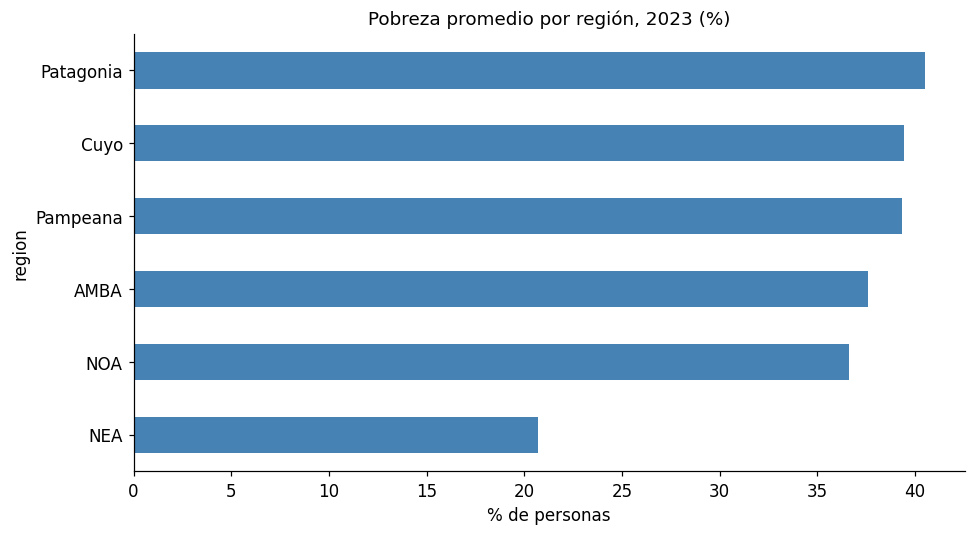

In [3]:
# Barras desde un groupby
ax = df.groupby('region')['pobreza_2023'].mean().sort_values().plot(
    kind='barh',
    color='steelblue',
    title='Pobreza promedio por región, 2023 (%)',
    figsize=(9, 5)
)
ax.set_xlabel("% de personas")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

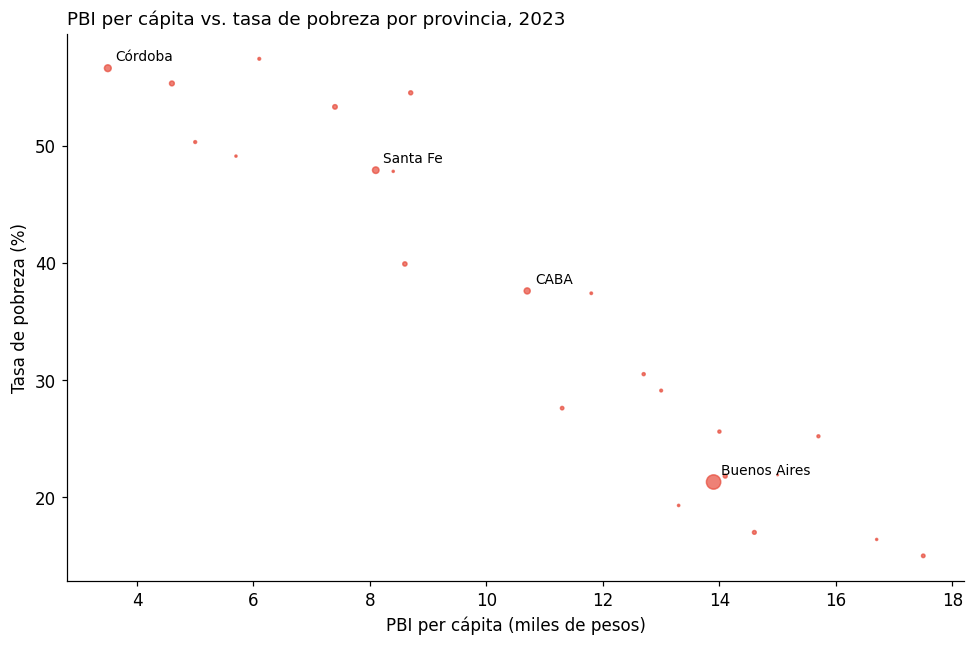

In [4]:
# Scatter desde pandas
ax = df.plot(
    kind='scatter',
    x='pbi_pc_miles',
    y='pobreza_2023',
    s=df['poblacion_miles'] / 200,  # tamaño proporcional a la población
    alpha=0.7,
    color='#e74c3c',
    figsize=(9, 6)
)
ax.set_title("PBI per cápita vs. tasa de pobreza por provincia, 2023", loc='left')
ax.set_xlabel("PBI per cápita (miles de pesos)")
ax.set_ylabel("Tasa de pobreza (%)")

# Etiquetar algunas provincias
for _, row in df[df['poblacion_miles'] > 2000].iterrows():
    ax.annotate(row['provincia'], (row['pbi_pc_miles'], row['pobreza_2023']),
                textcoords="offset points", xytext=(5, 5), fontsize=9)

plt.tight_layout()
plt.show()


---
## 2. Exploración visual de distribuciones

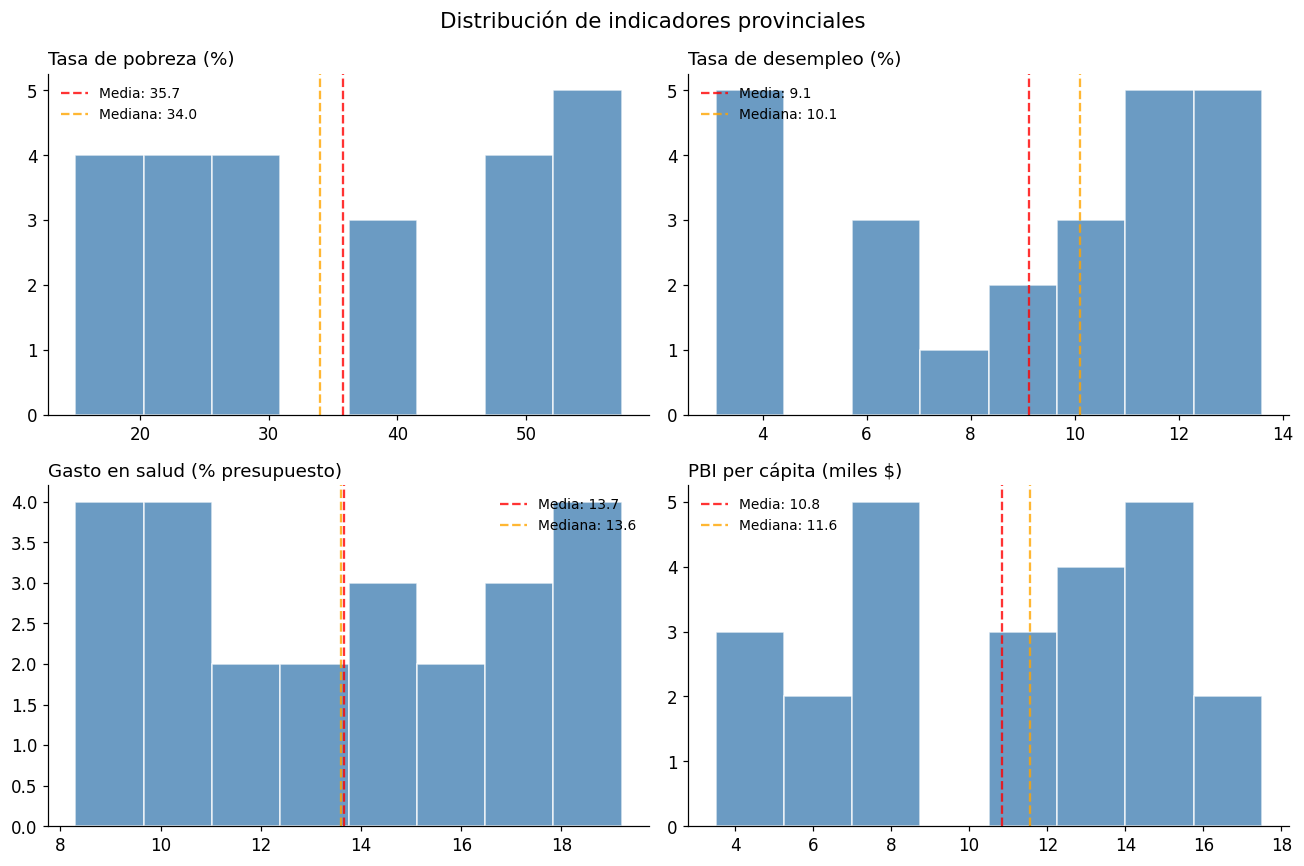

In [5]:
# Histogramas de múltiples variables
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Distribución de indicadores provinciales", fontsize=14)

variables = ['pobreza_2023', 'desempleo_2023', 'gasto_salud_pct', 'pbi_pc_miles']
titulos = ['Tasa de pobreza (%)', 'Tasa de desempleo (%)', 'Gasto en salud (% presupuesto)', 'PBI per cápita (miles $)']

for ax, var, titulo in zip(axes.flat, variables, titulos):
    ax.hist(df[var], bins=8, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df[var].mean(), color='red', linestyle='--', alpha=0.8, label=f'Media: {df[var].mean():.1f}')
    ax.axvline(df[var].median(), color='orange', linestyle='--', alpha=0.8, label=f'Mediana: {df[var].median():.1f}')
    ax.set_title(titulo, loc='left')
    ax.legend(fontsize=9, frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


---
## 3. Visualizar series temporales con pandas

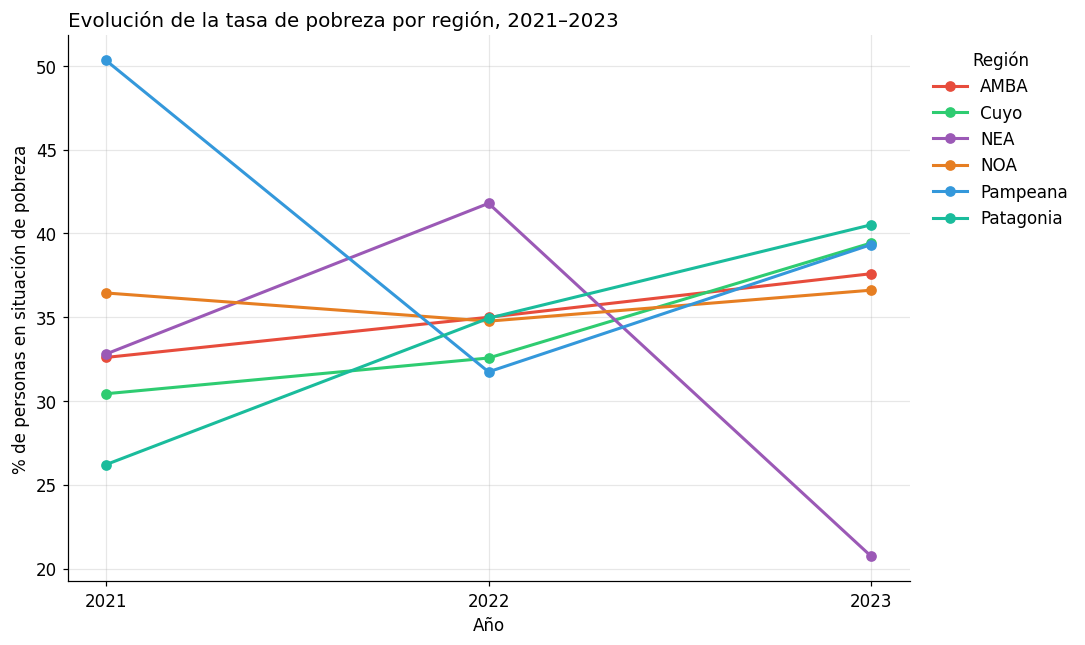

In [6]:
# Pasar a formato long para graficar series temporales
df_long = df[['provincia', 'region', 'pobreza_2021', 'pobreza_2022', 'pobreza_2023']].melt(
    id_vars=['provincia', 'region'],
    value_vars=['pobreza_2021', 'pobreza_2022', 'pobreza_2023'],
    var_name='anio',
    value_name='pobreza'
)
df_long['anio'] = df_long['anio'].str.extract(r'(\d{4})').astype(int)

# Promediar por región
serie_region = df_long.groupby(['region', 'anio'])['pobreza'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

colores = {'AMBA': '#e74c3c', 'Pampeana': '#3498db', 'Cuyo': '#2ecc71',
           'NOA': '#e67e22', 'NEA': '#9b59b6', 'Patagonia': '#1abc9c'}

for region, grupo in serie_region.groupby('region'):
    ax.plot(grupo['anio'], grupo['pobreza'],
            marker='o', label=region, color=colores.get(region, 'gray'), linewidth=2)

ax.set_title("Evolución de la tasa de pobreza por región, 2021–2023", fontsize=13, loc='left')
ax.set_xlabel("Año")
ax.set_ylabel("% de personas en situación de pobreza")
ax.set_xticks([2021, 2022, 2023])
ax.legend(title='Región', bbox_to_anchor=(1.01, 1), frameon=False, loc='upper left')
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


---
## 4. Detección visual de outliers (boxplots)

/var/folders/8j/y_l8frxs2n19mq92k5pv4y100000gn/T/ipykernel_12712/1465349362.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_por_region, labels=regiones_orden, patch_artist=True,


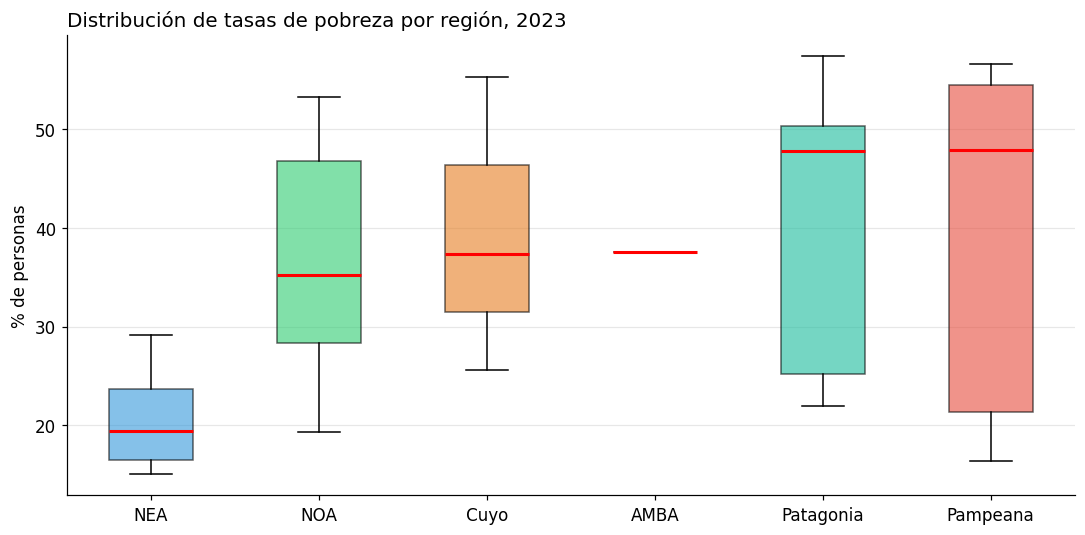

In [7]:
# Boxplot de pobreza por región
regiones_orden = df.groupby('region')['pobreza_2023'].median().sort_values().index.tolist()
datos_por_region = [df[df['region'] == r]['pobreza_2023'].values for r in regiones_orden]

fig, ax = plt.subplots(figsize=(10, 5))

bp = ax.boxplot(datos_por_region, labels=regiones_orden, patch_artist=True,
                medianprops=dict(color='red', linewidth=2))

colores_lista = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#1abc9c', '#e74c3c']
for patch, color in zip(bp['boxes'], colores_lista):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_title("Distribución de tasas de pobreza por región, 2023", fontsize=13, loc='left')
ax.set_ylabel("% de personas")
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


---
## 5. Dashboard completo: análisis exploratorio

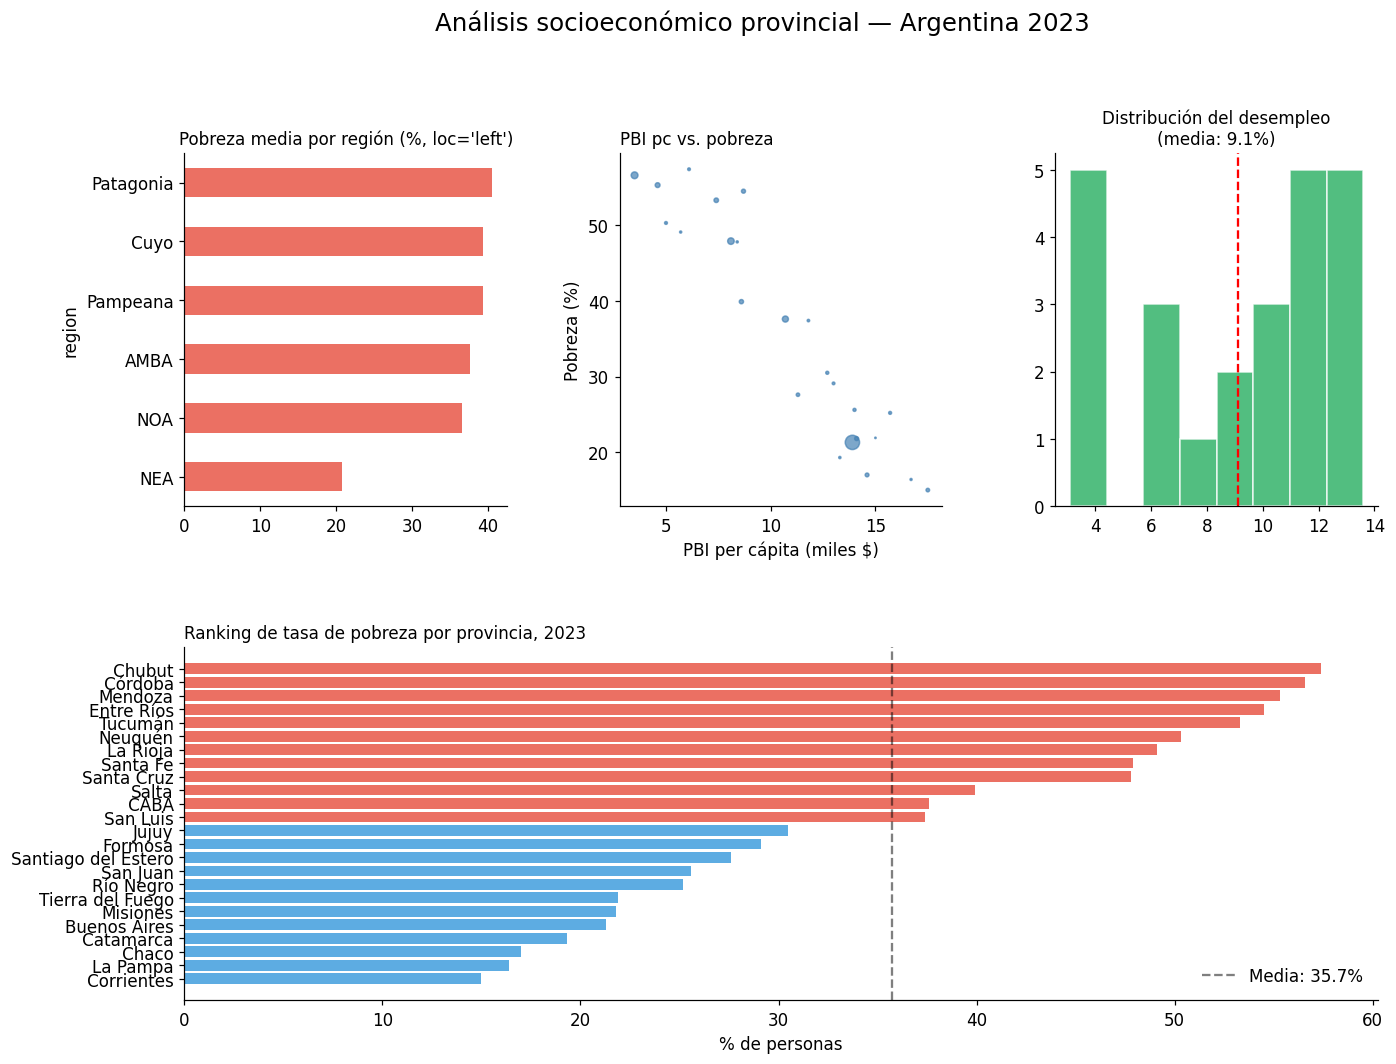

Dashboard guardado como dashboard_provincial.png


In [8]:
fig = plt.figure(figsize=(14, 10))
fig.suptitle("Análisis socioeconómico provincial — Argentina 2023",
             fontsize=16, y=1.01)

# Layout: 2 filas, 3 columnas
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])  # barras
ax2 = fig.add_subplot(gs[0, 1])  # scatter
ax3 = fig.add_subplot(gs[0, 2])  # hist
ax4 = fig.add_subplot(gs[1, :])  # ranking ancho

# Panel 1: Pobreza promedio por región
resumen_reg = df.groupby('region')['pobreza_2023'].mean().sort_values()
resumen_reg.plot(kind='barh', ax=ax1, color='#e74c3c', alpha=0.8)
ax1.set_title("Pobreza media por región (%, loc='left')", fontsize=11)
ax1.set_xlabel("")
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Panel 2: Scatter PBI vs pobreza
ax2.scatter(df['pbi_pc_miles'], df['pobreza_2023'], alpha=0.7, color='steelblue',
            s=df['poblacion_miles'] / 200)
ax2.set_title("PBI pc vs. pobreza", fontsize=11, loc='left')
ax2.set_xlabel("PBI per cápita (miles $)")
ax2.set_ylabel("Pobreza (%)")
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Panel 3: Distribución de desempleo
ax3.hist(df['desempleo_2023'], bins=8, color='#27ae60', edgecolor='white', alpha=0.8)
ax3.axvline(df['desempleo_2023'].mean(), color='red', linestyle='--')
ax3.set_title(f"Distribución del desempleo\n(media: {df['desempleo_2023'].mean():.1f}%)", fontsize=11)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Panel 4: Ranking de provincias por pobreza
ranking = df.sort_values('pobreza_2023', ascending=True)
colores_bar = ['#e74c3c' if p > df['pobreza_2023'].mean() else '#3498db'
               for p in ranking['pobreza_2023']]
ax4.barh(ranking['provincia'], ranking['pobreza_2023'], color=colores_bar, alpha=0.8)
ax4.axvline(df['pobreza_2023'].mean(), color='black', linestyle='--', alpha=0.5,
            label=f'Media: {df["pobreza_2023"].mean():.1f}%')
ax4.set_title("Ranking de tasa de pobreza por provincia, 2023", fontsize=11, loc='left')
ax4.set_xlabel("% de personas")
ax4.legend(frameon=False)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.savefig("dashboard_provincial.png", dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard guardado como dashboard_provincial.png")


---
## 7. Ejercicios

### Ejercicio 1
Usando el DataFrame `df`, creá un gráfico de barras agrupadas que muestre el gasto en salud y el gasto en educación por región (una barra de cada color por región, lado a lado).

In [9]:
# Tu solución aquí
# Pista: groupby('region')[['gasto_salud_pct','gasto_educacion_pct']].mean().plot(kind='bar')


### Ejercicio 2
Identificá las 5 provincias con la mayor **variación** en la tasa de pobreza entre 2021 y 2023 (en valor absoluto). Mostrá sus trayectorias en un line plot.

In [10]:
# Tu solución aquí
